# 08 — Convert Official CASIA-B Silhouettes to NPZ

আপনার CASIA-B official silhouettes এই structure-এ আছে:

```text
/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/silhouettes/
├── 001/
│   ├── bg-01/
│   │   ├── 000/
│   │   │   ├── 001-bg-01-000-001.png
│   │   │   ├── 001-bg-01-000-002.png
│   │   │   └── ...
│   │   ├── 018/
│   │   └── ...
│   ├── bg-02/
│   ├── cl-01/
│   ├── cl-02/
│   ├── nm-01/
│   └── nm-06/
├── 002/
└── 124/
```

This notebook converts official silhouette PNG frames into compact `.npz` files:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44/
├── 001/
│   ├── bg-01/
│   │   └── 000.npz
│   └── ...
└── 124/
```

Each output `.npz` contains:

```text
silhouettes      uint8, shape T × 64 × 44, values 0/255
frame_valid      bool, shape T
frame_indices    int32, shape T
source_frame_paths
subject
condition
seq
view
```

Important:

- This uses official CASIA-B silhouettes, not YOLO segmentation.
- After this notebook, run `09_validate_silhouette_skeleton_alignment.ipynb`.
- In notebook 09 set:

```python
SILHOUETTE_TAG = "casiab_official_64x44"
```

In [1]:
# ============================================================
# CELL 1 — Imports, paths, config
# ============================================================

from pathlib import Path
import re
import tarfile
import time
import json
import traceback
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# Source official silhouettes
OFFICIAL_SIL_DIR = Path("/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/silhouettes")

# Experiment output root
EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

OUT_TAG = "casiab_official_64x44"
OUT_ROOT = EXP_DIR / "data" / "silhouettes" / OUT_TAG

REPORT_DIR = EXP_DIR / "data" / "reports"
INDEX_DIR = EXP_DIR / "data" / "index"
VIS_DIR = EXP_DIR / "visuals" / "official_silhouette_debug"

for d in [OUT_ROOT, REPORT_DIR, INDEX_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Output silhouette size used by common gait silhouette baselines
SIL_H = 64
SIL_W = 44

# If tar.gz files exist and subject folders are missing, extract them safely
EXTRACT_TARS_IF_NEEDED = True

# Convert silhouettes
RUN_FULL_CONVERSION = True
OVERWRITE = False

# Debug visuals
SAVE_DEBUG_VIS_N = 80
VIS_FRAME_COUNT = 8

# Official CASIA-B expected counts
EXPECTED_SUBJECTS = 124
EXPECTED_CONDITIONS_PER_SUBJECT = 10
EXPECTED_VIEWS = 11
EXPECTED_SAMPLES = EXPECTED_SUBJECTS * EXPECTED_CONDITIONS_PER_SUBJECT * EXPECTED_VIEWS

print("=" * 80)
print("Official CASIA-B Silhouette Converter")
print("=" * 80)
print("OFFICIAL_SIL_DIR:", OFFICIAL_SIL_DIR)
print("EXP_DIR         :", EXP_DIR)
print("OUT_ROOT        :", OUT_ROOT)
print("REPORT_DIR      :", REPORT_DIR)
print("VIS_DIR         :", VIS_DIR)
print("Output size     :", f"{SIL_H}x{SIL_W}")
print("=" * 80)

assert OFFICIAL_SIL_DIR.exists(), f"Missing source silhouette folder: {OFFICIAL_SIL_DIR}"

Official CASIA-B Silhouette Converter
OFFICIAL_SIL_DIR: /media/wadud/DriveUbuntu/CASIA/Main/DatasetB/silhouettes
EXP_DIR         : /media/wadud/DriveUbuntu/GaitRecognition 2.0
OUT_ROOT        : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44
REPORT_DIR      : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports
VIS_DIR         : /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/official_silhouette_debug
Output size     : 64x44


In [2]:
# ============================================================
# CELL 2 — Optional safe extraction of subject tar.gz files
# ============================================================

def is_safe_tar_member(base_dir: Path, member_name: str):
    # Prevent path traversal when extracting tar files.
    target = (base_dir / member_name).resolve()
    base = base_dir.resolve()
    return str(target).startswith(str(base))

def safe_extract_tar_gz(tar_path: Path, extract_to: Path):
    with tarfile.open(tar_path, "r:gz") as tar:
        members = tar.getmembers()

        for m in members:
            if not is_safe_tar_member(extract_to, m.name):
                raise RuntimeError(f"Unsafe tar member path: {m.name}")

        tar.extractall(extract_to)

def maybe_extract_subject_tars():
    tar_files = sorted(OFFICIAL_SIL_DIR.glob("*.tar.gz"))

    if not tar_files:
        print("No .tar.gz files found. Skipping extraction.")
        return

    extracted = []
    skipped = []
    failed = []

    for tar_path in tqdm(tar_files, desc="Checking/extracting tar.gz"):
        subject = tar_path.name.split(".")[0]  # 001.tar.gz -> 001
        subject_dir = OFFICIAL_SIL_DIR / subject

        if subject_dir.exists() and any(subject_dir.iterdir()):
            skipped.append(str(tar_path))
            continue

        try:
            safe_extract_tar_gz(tar_path, OFFICIAL_SIL_DIR)
            extracted.append(str(tar_path))
        except Exception as e:
            failed.append({"tar_path": str(tar_path), "error": str(e)})

    print("Tar files found :", len(tar_files))
    print("Extracted      :", len(extracted))
    print("Skipped exists :", len(skipped))
    print("Failed         :", len(failed))

    if failed:
        failed_csv = REPORT_DIR / "official_silhouette_tar_extract_failed.csv"
        pd.DataFrame(failed).to_csv(failed_csv, index=False)
        print("Failed report:", failed_csv)

if EXTRACT_TARS_IF_NEEDED:
    maybe_extract_subject_tars()
else:
    print("EXTRACT_TARS_IF_NEEDED=False")

Checking/extracting tar.gz:   0%|          | 0/124 [00:00<?, ?it/s]

Tar files found : 124
Extracted      : 124
Skipped exists : 0
Failed         : 0


In [3]:
# ============================================================
# CELL 3 — Discover official silhouette samples
# ============================================================

VALID_CONDITIONS = {"nm", "bg", "cl"}
VALID_VIEWS = {"000", "018", "036", "054", "072", "090", "108", "126", "144", "162", "180"}

FRAME_FILE_RE = re.compile(
    r"^(?P<subject>\d{3})-(?P<condition>nm|bg|cl)-(?P<seq>\d{2})-(?P<view>\d{3})-(?P<frame>\d+)\.(png|jpg|jpeg|bmp)$",
    re.IGNORECASE
)

def parse_condition_seq(name: str):
    # bg-01, cl-02, nm-06
    if "-" not in name:
        return None

    condition, seq = name.split("-", 1)

    if condition not in VALID_CONDITIONS:
        return None

    if not seq.isdigit():
        return None

    return condition, seq

def discover_official_samples(root: Path):
    records = []
    skipped = []

    subject_dirs = sorted([p for p in root.iterdir() if p.is_dir() and re.fullmatch(r"\d{3}", p.name)])

    for subject_dir in subject_dirs:
        subject = subject_dir.name

        cond_dirs = sorted([p for p in subject_dir.iterdir() if p.is_dir()])

        for cond_dir in cond_dirs:
            parsed = parse_condition_seq(cond_dir.name)
            if parsed is None:
                skipped.append({"path": str(cond_dir), "reason": "bad_condition_seq_folder"})
                continue

            condition, seq = parsed

            view_dirs = sorted([p for p in cond_dir.iterdir() if p.is_dir()])

            for view_dir in view_dirs:
                view = view_dir.name

                if view not in VALID_VIEWS:
                    skipped.append({"path": str(view_dir), "reason": "bad_view_folder"})
                    continue

                frame_files = sorted([
                    p for p in view_dir.iterdir()
                    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
                ])

                if len(frame_files) == 0:
                    skipped.append({"path": str(view_dir), "reason": "no_image_frames"})
                    continue

                records.append({
                    "subject": subject,
                    "condition": condition,
                    "seq": seq,
                    "view": view,
                    "sample_dir": str(view_dir),
                    "num_source_frames": len(frame_files),
                    "key": f"{subject}-{condition}-{seq}-{view}",
                })

    return records, skipped

records, skipped = discover_official_samples(OFFICIAL_SIL_DIR)

df_index = pd.DataFrame(records)
df_skipped = pd.DataFrame(skipped)

index_csv = INDEX_DIR / "official_casiab_silhouette_sample_index.csv"
skipped_csv = REPORT_DIR / "official_casiab_silhouette_discovery_skipped.csv"

df_index.to_csv(index_csv, index=False)
df_skipped.to_csv(skipped_csv, index=False)

print("Discovered samples:", len(df_index))
print("Expected samples  :", EXPECTED_SAMPLES)
print("Skipped dirs      :", len(df_skipped))
print("Index saved       :", index_csv)
print("Skipped saved     :", skipped_csv)

if len(df_index) > 0:
    display(df_index.head())
    display(df_index.tail())
    display(df_index.groupby(["condition", "seq"]).size().reset_index(name="count"))

Discovered samples: 13593
Expected samples  : 13640
Skipped dirs      : 47
Index saved       : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/index/official_casiab_silhouette_sample_index.csv
Skipped saved     : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_casiab_silhouette_discovery_skipped.csv


,subject,condition,seq,view,sample_dir,num_source_frames,key
0,001,bg,01,000,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,89,001-bg-01-000
1,001,bg,01,018,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,91,001-bg-01-018
2,001,bg,01,036,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,87,001-bg-01-036
3,001,bg,01,054,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,87,001-bg-01-054
4,001,bg,01,072,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,60,001-bg-01-072


,subject,condition,seq,view,sample_dir,num_source_frames,key
13588,124,nm,06,108,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,51,124-nm-06-108
13589,124,nm,06,126,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,67,124-nm-06-126
13590,124,nm,06,144,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,71,124-nm-06-144
13591,124,nm,06,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,74,124-nm-06-162
13592,124,nm,06,180,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,74,124-nm-06-180


,condition,seq,count
0,bg,01,1360
1,bg,02,1358
2,cl,01,1362
3,cl,02,1358
4,nm,01,1355
5,nm,02,1361
6,nm,03,1356
7,nm,04,1357
8,nm,05,1363
9,nm,06,1363


In [4]:
# ============================================================
# CELL 4 — Frame sorting and silhouette standardization
# ============================================================

def frame_number_from_path(path: Path):
    m = FRAME_FILE_RE.match(path.name)
    if m is not None:
        return int(m.group("frame"))

    # Fallback: last number in filename
    nums = re.findall(r"\d+", path.stem)
    if nums:
        return int(nums[-1])

    return 0

def list_sorted_frame_files(sample_dir: Path):
    frame_files = [
        p for p in sample_dir.iterdir()
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
    ]

    frame_files = sorted(frame_files, key=lambda p: (frame_number_from_path(p), p.name))
    return frame_files

def read_binary_silhouette_image(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise RuntimeError(f"Could not read image: {path}")

    # Official CASIA-B silhouettes are binary-ish.
    # Use >0 to keep all foreground pixels.
    binary = (img > 0).astype(np.uint8)

    return binary

def clean_mask(mask):
    mask = mask.astype(np.uint8)

    if mask.sum() == 0:
        return mask

    # Very light cleanup only. Official silhouettes should already be clean.
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

def standardize_silhouette(mask, out_h=64, out_w=44):
    # Convert an official silhouette frame to 64x44:
    # 1. binary mask
    # 2. bbox crop foreground
    # 3. resize height to 64 preserving aspect ratio
    # 4. center crop/pad width to 44
    mask = clean_mask(mask)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return np.zeros((out_h, out_w), dtype=np.uint8), False, [np.nan, np.nan, np.nan, np.nan]

    x1, x2 = int(xs.min()), int(xs.max()) + 1
    y1, y2 = int(ys.min()), int(ys.max()) + 1

    crop = mask[y1:y2, x1:x2]

    h, w = crop.shape
    if h <= 0 or w <= 0:
        return np.zeros((out_h, out_w), dtype=np.uint8), False, [np.nan, np.nan, np.nan, np.nan]

    new_w = max(1, int(round(w * (out_h / float(h)))))
    resized = cv2.resize(crop, (new_w, out_h), interpolation=cv2.INTER_NEAREST)

    if new_w > out_w:
        start = max(0, (new_w - out_w) // 2)
        resized = resized[:, start:start + out_w]
    elif new_w < out_w:
        canvas = np.zeros((out_h, out_w), dtype=np.uint8)
        start = (out_w - new_w) // 2
        canvas[:, start:start + new_w] = resized
        resized = canvas

    sil = (resized > 0).astype(np.uint8) * 255

    return sil, True, [x1, y1, x2, y2]

def output_npz_path(record):
    return OUT_ROOT / record["subject"] / f"{record['condition']}-{record['seq']}" / f"{record['view']}.npz"

def output_vis_path(record):
    return VIS_DIR / f"{record['subject']}-{record['condition']}-{record['seq']}-{record['view']}.png"

In [5]:
# ============================================================
# CELL 5 — Convert one sample
# ============================================================

def make_debug_sheet(sils, frame_ids, title_text=None):
    if len(sils) == 0:
        return None

    n = len(sils)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))

    if n == 1:
        axes = [axes]

    for ax, sil, frame_id in zip(axes, sils, frame_ids):
        ax.imshow(sil, cmap="gray")
        ax.set_title(f"f={frame_id}")
        ax.axis("off")

    if title_text:
        fig.suptitle(title_text)

    fig.tight_layout()
    return fig

def convert_one_sample(record, save_debug=False):
    sample_dir = Path(record["sample_dir"])
    out_path = output_npz_path(record)

    if out_path.exists() and not OVERWRITE:
        return {
            "status": "skipped_exists",
            "key": record["key"],
            "subject": record["subject"],
            "condition": record["condition"],
            "seq": record["seq"],
            "view": record["view"],
            "sample_dir": str(sample_dir),
            "out_npz": str(out_path),
            "num_source_frames": record["num_source_frames"],
            "frame_count_processed": "",
            "valid_frame_ratio": "",
            "mean_foreground_area": "",
            "error": "",
        }

    frame_files = list_sorted_frame_files(sample_dir)

    if len(frame_files) == 0:
        raise RuntimeError(f"No image frames found in {sample_dir}")

    silhouettes = []
    frame_valid = []
    frame_indices = []
    bboxes = []
    source_frame_paths = []
    foreground_areas = []

    for frame_path in frame_files:
        frame_no = frame_number_from_path(frame_path)

        binary = read_binary_silhouette_image(frame_path)
        sil, valid, bbox = standardize_silhouette(binary, SIL_H, SIL_W)

        silhouettes.append(sil)
        frame_valid.append(bool(valid))
        frame_indices.append(int(frame_no))
        bboxes.append(bbox)
        source_frame_paths.append(str(frame_path))
        foreground_areas.append(float((sil > 0).sum()))

    silhouettes = np.stack(silhouettes, axis=0).astype(np.uint8)
    frame_valid = np.asarray(frame_valid, dtype=np.bool_)
    frame_indices = np.asarray(frame_indices, dtype=np.int32)
    bboxes = np.asarray(bboxes, dtype=np.float32)
    foreground_areas = np.asarray(foreground_areas, dtype=np.float32)
    source_frame_paths = np.asarray(source_frame_paths)

    out_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_path,
        silhouettes=silhouettes,
        frame_valid=frame_valid,
        frame_indices=frame_indices,
        bboxes=bboxes,
        foreground_areas=foreground_areas,
        source_frame_paths=source_frame_paths,

        subject=np.array(record["subject"]),
        condition=np.array(record["condition"]),
        seq=np.array(record["seq"]),
        view=np.array(record["view"]),
        key=np.array(record["key"]),
        source_sample_dir=np.array(str(sample_dir)),
        output_tag=np.array(OUT_TAG),
        silhouette_height=np.array(SIL_H, dtype=np.int32),
        silhouette_width=np.array(SIL_W, dtype=np.int32),
        frame_count_processed=np.array(len(silhouettes), dtype=np.int32),
    )

    if save_debug:
        n = min(VIS_FRAME_COUNT, len(silhouettes))
        frame_ids = np.linspace(0, len(silhouettes) - 1, num=n).astype(int)
        fig = make_debug_sheet(
            [silhouettes[i] for i in frame_ids],
            [int(frame_indices[i]) for i in frame_ids],
            title_text=record["key"]
        )
        if fig is not None:
            vis_path = output_vis_path(record)
            vis_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(vis_path, dpi=120)
            plt.close(fig)

    valid_frame_ratio = float(frame_valid.mean()) if len(frame_valid) else 0.0
    mean_foreground_area = float(foreground_areas.mean()) if len(foreground_areas) else 0.0

    return {
        "status": "ok",
        "key": record["key"],
        "subject": record["subject"],
        "condition": record["condition"],
        "seq": record["seq"],
        "view": record["view"],
        "sample_dir": str(sample_dir),
        "out_npz": str(out_path),
        "num_source_frames": record["num_source_frames"],
        "frame_count_processed": int(len(silhouettes)),
        "valid_frame_ratio": valid_frame_ratio,
        "mean_foreground_area": mean_foreground_area,
        "error": "",
    }

In [6]:
# ============================================================
# CELL 6 — Test conversion on a few samples
# ============================================================

TEST_N = 5

if len(records) == 0:
    raise RuntimeError("No official silhouette samples found.")

test_rows = []
for rec in tqdm(records[:TEST_N], desc=f"Testing first {TEST_N} official samples"):
    try:
        row = convert_one_sample(rec, save_debug=True)
        test_rows.append(row)
    except Exception as e:
        test_rows.append({
            "status": "failed",
            "key": rec["key"],
            "subject": rec["subject"],
            "condition": rec["condition"],
            "seq": rec["seq"],
            "view": rec["view"],
            "sample_dir": rec["sample_dir"],
            "out_npz": str(output_npz_path(rec)),
            "num_source_frames": rec["num_source_frames"],
            "frame_count_processed": "",
            "valid_frame_ratio": "",
            "mean_foreground_area": "",
            "error": str(e),
        })
        print("FAILED:", rec["key"])
        print(traceback.format_exc())

df_test = pd.DataFrame(test_rows)
display(df_test)

print("Debug visuals:", VIS_DIR)

Testing first 5 official samples:   0%|          | 0/5 [00:00<?, ?it/s]

,status,key,subject,condition,seq,view,sample_dir,out_npz,num_source_frames,frame_count_processed,valid_frame_ratio,mean_foreground_area,error
0,ok,001-bg-01-000,001,bg,01,000,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,89,89,1.0,776.910095,
1,ok,001-bg-01-018,001,bg,01,018,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,91,91,1.0,753.780212,
2,ok,001-bg-01-036,001,bg,01,036,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,87,87,1.0,745.689636,
3,ok,001-bg-01-054,001,bg,01,054,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,87,87,1.0,752.850586,
4,ok,001-bg-01-072,001,bg,01,072,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,60,60,1.0,764.116638,


Debug visuals: /media/wadud/DriveUbuntu/GaitRecognition 2.0/visuals/official_silhouette_debug


Debug files: 5


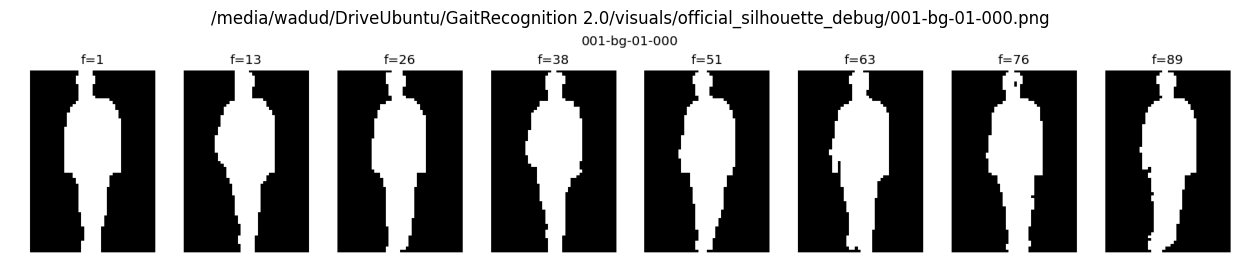

In [7]:
# ============================================================
# CELL 7 — Show one debug visual
# ============================================================

debug_files = sorted(VIS_DIR.glob("*.png"))

print("Debug files:", len(debug_files))

if debug_files:
    p = debug_files[0]
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)

    if img is not None:
        plt.figure(figsize=(16, 4))
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(str(p))
        plt.show()
    else:
        print("Could not read:", p)
else:
    print("No debug visual found yet.")

In [8]:
# ============================================================
# CELL 8 — Full conversion
# ============================================================

summary_rows = []
failed_rows = []

if RUN_FULL_CONVERSION:
    start_time = time.time()

    for i, rec in enumerate(tqdm(records, desc="Converting official CASIA-B silhouettes")):
        save_debug = i < SAVE_DEBUG_VIS_N

        try:
            row = convert_one_sample(rec, save_debug=save_debug)
            summary_rows.append(row)

        except Exception as e:
            err = traceback.format_exc()

            row = {
                "status": "failed",
                "key": rec["key"],
                "subject": rec["subject"],
                "condition": rec["condition"],
                "seq": rec["seq"],
                "view": rec["view"],
                "sample_dir": rec["sample_dir"],
                "out_npz": str(output_npz_path(rec)),
                "num_source_frames": rec["num_source_frames"],
                "frame_count_processed": "",
                "valid_frame_ratio": "",
                "mean_foreground_area": "",
                "error": str(e),
            }

            summary_rows.append(row)
            failed_rows.append({
                "key": rec["key"],
                "sample_dir": rec["sample_dir"],
                "error": err,
            })

        if len(summary_rows) % 500 == 0:
            pd.DataFrame(summary_rows).to_csv(
                REPORT_DIR / "official_silhouette_conversion_summary_partial.csv",
                index=False
            )

    elapsed = time.time() - start_time

    df_summary = pd.DataFrame(summary_rows)
    df_failed = pd.DataFrame(failed_rows)

    summary_csv = REPORT_DIR / "official_silhouette_conversion_summary.csv"
    failed_csv = REPORT_DIR / "official_silhouette_conversion_failed.csv"

    df_summary.to_csv(summary_csv, index=False)
    df_failed.to_csv(failed_csv, index=False)

    print("=" * 80)
    print("OFFICIAL SILHOUETTE CONVERSION DONE")
    print("=" * 80)
    print("Elapsed minutes:", elapsed / 60)
    print("Summary saved  :", summary_csv)
    print("Failed saved   :", failed_csv)
    print("Output root    :", OUT_ROOT)
    print("=" * 80)

    display(df_summary["status"].value_counts())

else:
    print("RUN_FULL_CONVERSION=False")

Converting official CASIA-B silhouettes:   0%|          | 0/13593 [00:00<?, ?it/s]

OFFICIAL SILHOUETTE CONVERSION DONE
Elapsed minutes: 8.200536187489828
Summary saved  : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_silhouette_conversion_summary.csv
Failed saved   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_silhouette_conversion_failed.csv
Output root    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44


status
ok                13588
skipped_exists        5
Name: count, dtype: int64

In [9]:
# ============================================================
# CELL 9 — Verify converted outputs
# ============================================================

sil_files = sorted(OUT_ROOT.rglob("*.npz"))

print("Total converted .npz files:", len(sil_files))
print("Expected full CASIA-B      :", EXPECTED_SAMPLES)
print("Output root               :", OUT_ROOT)

summary_csv = REPORT_DIR / "official_silhouette_conversion_summary.csv"

if summary_csv.exists():
    df_summary = pd.read_csv(summary_csv, dtype={
        "subject": str,
        "condition": str,
        "seq": str,
        "view": str,
    })

    print("\nStatus counts:")
    display(df_summary["status"].value_counts())

    ok_df = df_summary[df_summary["status"].isin(["ok", "skipped_exists"])].copy()

    if len(ok_df) > 0:
        print("\nFrame count / quality summary:")
        cols = ["num_source_frames", "frame_count_processed", "valid_frame_ratio", "mean_foreground_area"]
        display(ok_df[cols].describe())

        low_quality = ok_df[
            (pd.to_numeric(ok_df["valid_frame_ratio"], errors="coerce") < 0.95) |
            (pd.to_numeric(ok_df["mean_foreground_area"], errors="coerce") < 10)
        ].copy()

        low_quality_csv = REPORT_DIR / "official_silhouette_low_quality_files.csv"
        low_quality.to_csv(low_quality_csv, index=False)

        print("Low-quality converted samples:", len(low_quality))
        print("Saved:", low_quality_csv)

        if len(low_quality) > 0:
            display(low_quality.head(30))
else:
    print("No full summary CSV found:", summary_csv)

Total converted .npz files: 13593
Expected full CASIA-B      : 13640
Output root               : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44

Status counts:


status
ok                13588
skipped_exists        5
Name: count, dtype: int64


Frame count / quality summary:


,num_source_frames,frame_count_processed,valid_frame_ratio,mean_foreground_area
count,13593.000000,13588.000000,13588.000000,13588.000000
mean,82.275657,82.275464,0.998978,747.630765
std,21.083068,21.085791,0.016934,72.310130
min,1.000000,1.000000,0.000000,0.000000
25%,67.000000,67.000000,1.000000,700.660736
50%,80.000000,80.000000,1.000000,747.811768
75%,95.000000,95.000000,1.000000,795.499695
max,204.000000,204.000000,1.000000,1052.500000


Low-quality converted samples: 64
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_silhouette_low_quality_files.csv


,status,key,subject,condition,seq,view,sample_dir,out_npz,num_source_frames,frame_count_processed,valid_frame_ratio,mean_foreground_area,error
440,ok,005-bg-01-018,005,bg,01,018,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,71,71.0,0.859155,522.845093,NaN
447,ok,005-bg-01-144,005,bg,01,144,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,41,41.0,0.853659,546.707336,NaN
448,ok,005-bg-01-162,005,bg,01,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,92,92.0,0.608696,395.293488,NaN
456,ok,005-bg-02-126,005,bg,02,126,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,33,33.0,0.939394,533.878784,NaN
458,ok,005-bg-02-162,005,bg,02,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,88,88.0,0.693182,351.159088,NaN
475,ok,005-cl-02-108,005,cl,02,108,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,53,53.0,0.943396,643.471680,NaN
518,ok,005-nm-04-162,005,nm,04,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,63,63.0,0.857143,405.158722,NaN
1319,ok,013-bg-01-162,013,bg,01,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,123,123.0,0.739837,619.983765,NaN
1330,ok,013-bg-02-162,013,bg,02,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,112,112.0,0.848214,716.294617,NaN
1341,ok,013-cl-01-162,013,cl,01,162,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102,102.0,0.833333,708.098022,NaN


Sample file: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44/001/bg-01/000.npz
Keys: ['silhouettes', 'frame_valid', 'frame_indices', 'bboxes', 'foreground_areas', 'source_frame_paths', 'subject', 'condition', 'seq', 'view', 'key', 'source_sample_dir', 'output_tag', 'silhouette_height', 'silhouette_width', 'frame_count_processed']
silhouettes shape: (89, 64, 44)
frame_valid shape: (89,)
frame_indices first: [ 1  2  3  4  5  6  7  8  9 10]
subject: 001
condition: bg
seq: 01
view: 000


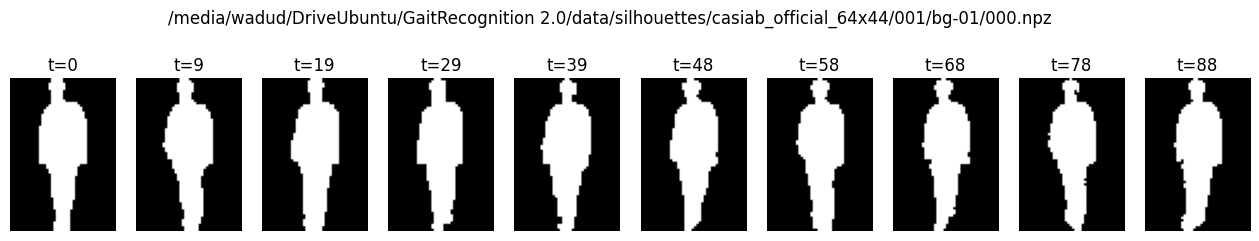

In [10]:
# ============================================================
# CELL 10 — Inspect one converted NPZ file
# ============================================================

sil_files = sorted(OUT_ROOT.rglob("*.npz"))

if not sil_files:
    print("No converted .npz files found.")
else:
    p = sil_files[0]
    data = np.load(p)

    print("Sample file:", p)
    print("Keys:", data.files)
    print("silhouettes shape:", data["silhouettes"].shape)
    print("frame_valid shape:", data["frame_valid"].shape)
    print("frame_indices first:", data["frame_indices"][:10])
    print("subject:", str(data["subject"]))
    print("condition:", str(data["condition"]))
    print("seq:", str(data["seq"]))
    print("view:", str(data["view"]))

    S = data["silhouettes"]
    frame_ids = np.linspace(0, len(S) - 1, num=min(10, len(S))).astype(int)

    plt.figure(figsize=(16, 3))
    for i, t in enumerate(frame_ids):
        plt.subplot(1, len(frame_ids), i + 1)
        plt.imshow(S[t], cmap="gray")
        plt.title(f"t={t}")
        plt.axis("off")
    plt.suptitle(str(p))
    plt.show()

In [11]:
# ============================================================
# CELL 11 — Save final metadata
# ============================================================

metadata = {
    "source_official_sil_dir": str(OFFICIAL_SIL_DIR),
    "experiment_dir": str(EXP_DIR),
    "output_root": str(OUT_ROOT),
    "output_tag": OUT_TAG,
    "silhouette_height": SIL_H,
    "silhouette_width": SIL_W,
    "num_discovered_samples": int(len(df_index)),
    "num_converted_npz": int(len(list(OUT_ROOT.rglob("*.npz")))),
    "expected_samples": EXPECTED_SAMPLES,
    "summary_csv": str(REPORT_DIR / "official_silhouette_conversion_summary.csv"),
    "index_csv": str(index_csv),
}

metadata_path = REPORT_DIR / "official_silhouette_conversion_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata:", metadata_path)
print(json.dumps(metadata, indent=2))

Saved metadata: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_silhouette_conversion_metadata.json
{
  "source_official_sil_dir": "/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/silhouettes",
  "experiment_dir": "/media/wadud/DriveUbuntu/GaitRecognition 2.0",
  "output_root": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44",
  "output_tag": "casiab_official_64x44",
  "silhouette_height": 64,
  "silhouette_width": 44,
  "num_discovered_samples": 13593,
  "num_converted_npz": 13593,
  "expected_samples": 13640,
  "summary_csv": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/official_silhouette_conversion_summary.csv",
  "index_csv": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/index/official_casiab_silhouette_sample_index.csv"
}


## Next step

After this notebook finishes, run:

```text
09_validate_silhouette_skeleton_alignment.ipynb
```

In notebook 09, set:

```python
SILHOUETTE_TAG = "casiab_official_64x44"
```

Expected output from notebook 09:

```text
data/fusion_index/multimodal_index.csv
data/fusion_index/alignment_report.csv
data/fusion_splits/train_LT_fusion.csv
data/fusion_splits/gallery_LT_fusion.csv
data/fusion_splits/probe_LT_nm_fusion.csv
data/fusion_splits/probe_LT_bg_fusion.csv
data/fusion_splits/probe_LT_cl_fusion.csv
```

In [12]:
from pathlib import Path

OUT_ROOT = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44")
sil_files = sorted(OUT_ROOT.rglob("*.npz"))

print(len(sil_files))
print(sil_files[0])

13593
/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44/001/bg-01/000.npz


In [13]:
from pathlib import Path
import pandas as pd
import re

OFFICIAL_SIL_DIR = Path("/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/silhouettes")
OUT_ROOT = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/casiab_official_64x44")
REPORT_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

subjects = [f"{i:03d}" for i in range(1, 125)]
conditions = (
    [f"bg-{i:02d}" for i in range(1, 3)] +
    [f"cl-{i:02d}" for i in range(1, 3)] +
    [f"nm-{i:02d}" for i in range(1, 7)]
)
views = ["000", "018", "036", "054", "072", "090", "108", "126", "144", "162", "180"]

expected = []
for sub in subjects:
    for cond_seq in conditions:
        condition, seq = cond_seq.split("-")
        for view in views:
            expected.append({
                "subject": sub,
                "condition": condition,
                "seq": seq,
                "cond_seq": cond_seq,
                "view": view,
                "key": f"{sub}-{condition}-{seq}-{view}",
                "source_dir": str(OFFICIAL_SIL_DIR / sub / cond_seq / view),
                "out_npz": str(OUT_ROOT / sub / cond_seq / f"{view}.npz"),
            })

df_expected = pd.DataFrame(expected)

def count_source_frames(source_dir):
    p = Path(source_dir)
    if not p.exists():
        return 0
    return len([
        x for x in p.iterdir()
        if x.is_file() and x.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
    ])

df_expected["source_dir_exists"] = df_expected["source_dir"].apply(lambda x: Path(x).exists())
df_expected["source_frame_count"] = df_expected["source_dir"].apply(count_source_frames)
df_expected["out_exists"] = df_expected["out_npz"].apply(lambda x: Path(x).exists())

df_missing_output = df_expected[~df_expected["out_exists"]].copy()
df_missing_source = df_expected[df_expected["source_frame_count"] == 0].copy()

missing_output_csv = REPORT_DIR / "missing_official_silhouette_npz_expected_keys.csv"
missing_source_csv = REPORT_DIR / "missing_official_silhouette_source_dirs_or_frames.csv"

df_missing_output.to_csv(missing_output_csv, index=False)
df_missing_source.to_csv(missing_source_csv, index=False)

print("Expected total:", len(df_expected))
print("Converted npz :", df_expected["out_exists"].sum())
print("Missing npz   :", len(df_missing_output))
print("Missing/empty source dirs:", len(df_missing_source))

print("\nMissing output samples:")
display(df_missing_output[["key", "source_dir_exists", "source_frame_count", "source_dir", "out_npz"]].head(100))

print("Saved:", missing_output_csv)
print("Saved:", missing_source_csv)

Expected total: 13640
Converted npz : 13593
Missing npz   : 47
Missing/empty source dirs: 47

Missing output samples:


,key,source_dir_exists,source_frame_count,source_dir,out_npz
440,005-bg-01-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
451,005-bg-02-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
462,005-cl-01-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
473,005-cl-02-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
484,005-nm-01-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
495,005-nm-02-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
506,005-nm-03-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
517,005-nm-04-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
528,005-nm-05-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
539,005-nm-06-000,True,0,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/s...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/missing_official_silhouette_npz_expected_keys.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/missing_official_silhouette_source_dirs_or_frames.csv
